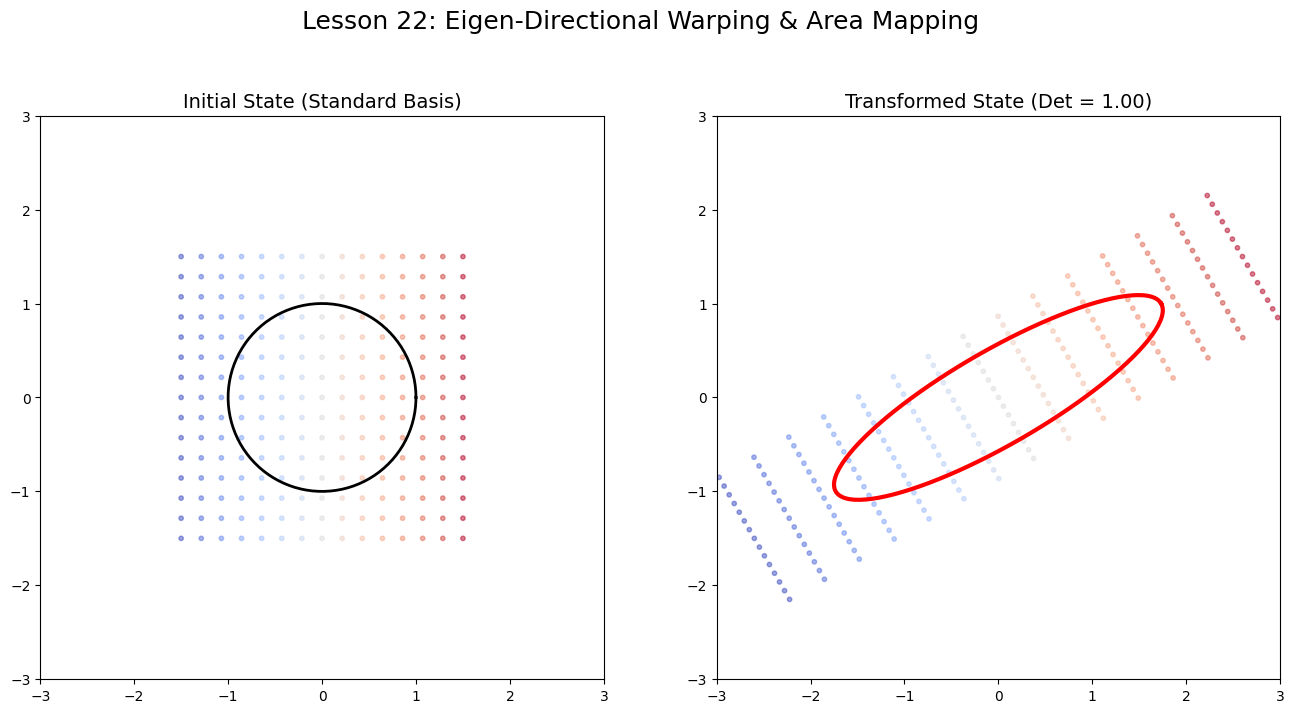

In [2]:
import numpy as np
import matplotlib.pyplot as plt
import os

def run_pro_transformation():
    # Birim çember noktaları (Daha estetik bir test objesi)
    t = np.linspace(0, 2*np.pi, 200)
    circle = np.array([np.cos(t), np.sin(t)])
    
    # Izgara noktaları
    grid_x, grid_y = np.meshgrid(np.linspace(-1.5, 1.5, 15), np.linspace(-1.5, 1.5, 15))
    grid = np.vstack([grid_x.ravel(), grid_y.ravel()])

    # Transformasyon Matrisi (Örn: Dönme + Uzatma)
    # A = [[cos, -sin], [sin, cos]] @ [[stretch, 0], [0, 1]]
    theta = np.radians(30)
    R = np.array([[np.cos(theta), -np.sin(theta)], [np.sin(theta), np.cos(theta)]])
    S = np.array([[2, 0], [0, 0.5]])
    A = R @ S 

    det_A = np.linalg.det(A)

    # Dönüşüm Uygula
    t_circle = A @ circle
    t_grid = A @ grid

    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 8))

    # 1. Orijinal Durum
    ax1.scatter(grid[0], grid[1], c=grid[0], cmap='coolwarm', s=10, alpha=0.5)
    ax1.plot(circle[0], circle[1], 'k', lw=2)
    ax1.set_title("Initial State (Standard Basis)", fontsize=14)
    ax1.set_xlim(-3, 3); ax1.set_ylim(-3, 3)
    ax1.set_aspect('equal')

    # 2. Dönüştürülmüş Durum
    ax2.scatter(t_grid[0], t_grid[1], c=grid[0], cmap='coolwarm', s=10, alpha=0.5)
    ax2.plot(t_circle[0], t_circle[1], 'r', lw=3)
    ax2.set_title(f"Transformed State (Det = {det_A:.2f})", fontsize=14)
    ax2.set_xlim(-3, 3); ax2.set_ylim(-3, 3)
    ax2.set_aspect('equal')

    plt.suptitle("Lesson 22: Eigen-Directional Warping & Area Mapping", fontsize=18)
    
    if not os.path.exists('../../../assets'): os.makedirs('../../../assets')
    plt.savefig('../../../assets/22_matrix_transform.png', dpi=300)
    plt.show()

if __name__ == "__main__":
    run_pro_transformation()